In [1]:
datasets = [
    # "fashion_mnist_red50_incremental",
    "mnist_red30_incremental",
    # "fashion_mnist_red50_sml",
    "mnist_red30_sml",
    # "fashion_mnist_red50_sml_3",
    # "mnist_red30_sml_3",
    # "fashion_mnist_red50_sml_2",
    # "mnist_red30_sml_2",
]
root = "/Users/federicogiannini/Library/CloudStorage/OneDrive-PolitecnicodiMilano/SML_CL"
nconfs = 10
save = True
suffixes = []
models_to_remove = ["ewc", "mir", "lwf", "hat", 'er_lwf', 'pnn']

In [2]:
import pickle
import matplotlib.pyplot as plt
import os 
import numpy as np
import pandas as pd
import scienceplots

In [40]:
def color(m):
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color'] + []
    extra_colors = [
        '#e41a1c',  # rosso vivo
        '#377eb8',  # blu acceso
        '#4daf4a',  # verde brillante
        '#984ea3',  # viola intenso
        '#ff7f00',  # arancione scuro
        '#ffff33',  # giallo limone (usa con sfondi scuri)
    ]
    colors += extra_colors
    models = ["naive"] + sorted([x for x in list(perf_values[0].keys()) if x!="drifts" and x!="naive"])
    models += models_to_remove
    i = [i for i in range(len(models)) if models[i]==m]
    if len(i)>0:
        i = i[0]
    else:
        i = 0
    return colors[i]

In [62]:
cm = 1 / 2.54

def plot_metric(perf_values, root, dataset, perf="concept", metric="kappa"):
    plt.figure(figsize=(13.7*cm, 4*cm))
    plt.style.use(['science', 'ieee'])
    plt.rcParams.update({'font.size': 8})

    values_list = []
    max_values = []
    for m in perf_values:
        if m=="drifts":
            continue
        values = perf_values[m][perf][metric]
        drifts_ = [0]+perf_values["drifts"][:-1]
        for i in range(len(drifts_)-1):
            values_list.append(min(values[drifts_[i]+5000:drifts_[i+1]]))
            max_values.append(max(values[drifts_[i]+5000:drifts_[i+1]]))
        plt.plot(range(len(values)), values, label=m, color=color(m), linestyle="solid")            

    for drift in perf_values["drifts"]:
        plt.axvline(x=drift, color='grey', linestyle='solid', linewidth=1)

    plt.xlabel("Data points")
    if metric=="kappa":
        plt.ylabel("Cohen's Kappa")
    else:
        plt.ylabel("Accuracy")

    if "sml" in dataset:
        scenario = "Real drift scenario"
        scenario_str = "real"
        plt.ylim(0.6,1)
    else:
        scenario = "Virtual drift scenario"
        scenario_str = "virtual"
        plt.ylim(0.9,1)
    if "concept" in perf:
        perf_type = "Task performance"
        perf_type_str = "task"
    else:
        perf_type = "Window performance"
        perf_type_str = "window"
    #plt.title(f"{scenario}")
    # plt.ylim(min(values_list),max(max_values)+0.005)
    plt.xlim(0, len(values))
    plt.gcf().subplots_adjust(left=0.15, right=0.95, top=0.9, bottom=0.15)
    xtick_labels = [f"drift$_{i}$" for i in range(1, len(perf_values["drifts"]))]
    plt.xticks(perf_values["drifts"][:-1], xtick_labels, rotation=90)
    plt.tick_params(axis='x', which='minor', bottom=False, top=False)


    # Salva la figura rispettando le dimensioni esatte
    if save:
        plt.gcf().savefig(
            os.path.join(root, f"{dataset.split('_red')[0]}_prequential_{scenario_str}_{perf_type_str}_{metric}.png"),
            dpi=300,
            bbox_inches='tight',  # Include tutto
            pad_inches=0,         # Margine minimo per rispettare la dimensione
        )
        plt.gcf().savefig(
            os.path.join(root, f"{dataset.split('_red')[0]}_prequential_{scenario_str}_{perf_type_str}_{metric}.eps"),
            bbox_inches='tight',  # Include tutto
            pad_inches=0,         # Margine minimo per rispettare la dimensione
            format="eps"
        )
    display(plt.gcf())
    plt.close(plt.gcf())

In [20]:
if type(nconfs)==int:
    nconfs = [nconfs] * len(datasets)

perf_values_final = {}
for dataset, nconf in zip(datasets, nconfs):
    perf_values = []
    lens = []
    for conf in range(1, nconf+1):
        lens.append(len(pd.read_csv(os.path.join(root, "datasets", f"{dataset}_{conf}conf_train.csv"))))
        with open(os.path.join(root, "performance", f"{dataset}_{conf}conf", f"performance_sml.pkl"), "rb") as f:
            perf_values_ = pickle.load(f)    
    
        with open(os.path.join(root, "performance", f"{dataset}_{conf}conf", "performance_cl.pkl"), "rb") as f:
            p = pickle.load(f)
            del p["drifts"]
            perf_values_.update(p)
    
        for s in suffixes:
            with open(os.path.join(root, "performance", f"{dataset}_{conf}conf", f"performance_cl_{s}.pkl"), "rb") as f:
                p = pickle.load(f)
                del p["drifts"]
                perf_values_.update(p)
            
        perf_values.append(perf_values_)
    
    drifts = [p["drifts"] for p in perf_values]
    for i in range(len(drifts)):
        drifts[i] = [0] + drifts[i] + [lens[i]]
    
    concepts_len = [[d[i+1]-d[i] for i in range(len(d)-1)] for d in drifts]
    concepts_len = np.min(concepts_len, axis=0)
    concepts_len
    
    perf_values_cleaned = pickle.loads(pickle.dumps(perf_values))
    for i in range(len(perf_values)):
        for model in perf_values[i]:
            if model=="drifts" or model in models_to_remove:
                continue
            for m in perf_values[i][model]:
                if m=="drifts":
                    continue
                for metric in ['accuracy', 'kappa']:
                    p = perf_values[i][model][m][metric]
                    perf_values_cleaned[i][model][m][metric] = np.concatenate(
                        [
                            p[drifts[i][j]:drifts[i][j]+concepts_len[j]]
                            for j in range(len(concepts_len))
                        ]
                    )
    
    for i in range(len(perf_values_cleaned)):
        perf_values_cleaned[i]["drifts"] = [concepts_len[0]]
        for j in range(1, len(concepts_len)):
            perf_values_cleaned[i]["drifts"].append(perf_values_cleaned[i]["drifts"][-1] + concepts_len[j])
    
    perf_values_final[dataset] = {}
    for model in perf_values_cleaned[0]:
        if model=="drifts" or model in models_to_remove:
            continue
        
        perf_values_final[dataset][model] = {}
        for m in perf_values_cleaned[0][model]:
            if "freezed" in m:
                continue
            perf_values_final[dataset][model][m] = {}
            for metric in ['accuracy', 'kappa']:
                perf_values_final[dataset][model][m][metric] = np.mean([p[model][m][metric] for p in perf_values_cleaned], axis=0)
    
    perf_values_final[dataset]["drifts"] = perf_values_cleaned[0]["drifts"]

mnist_red30_incremental rolling_reset_1000


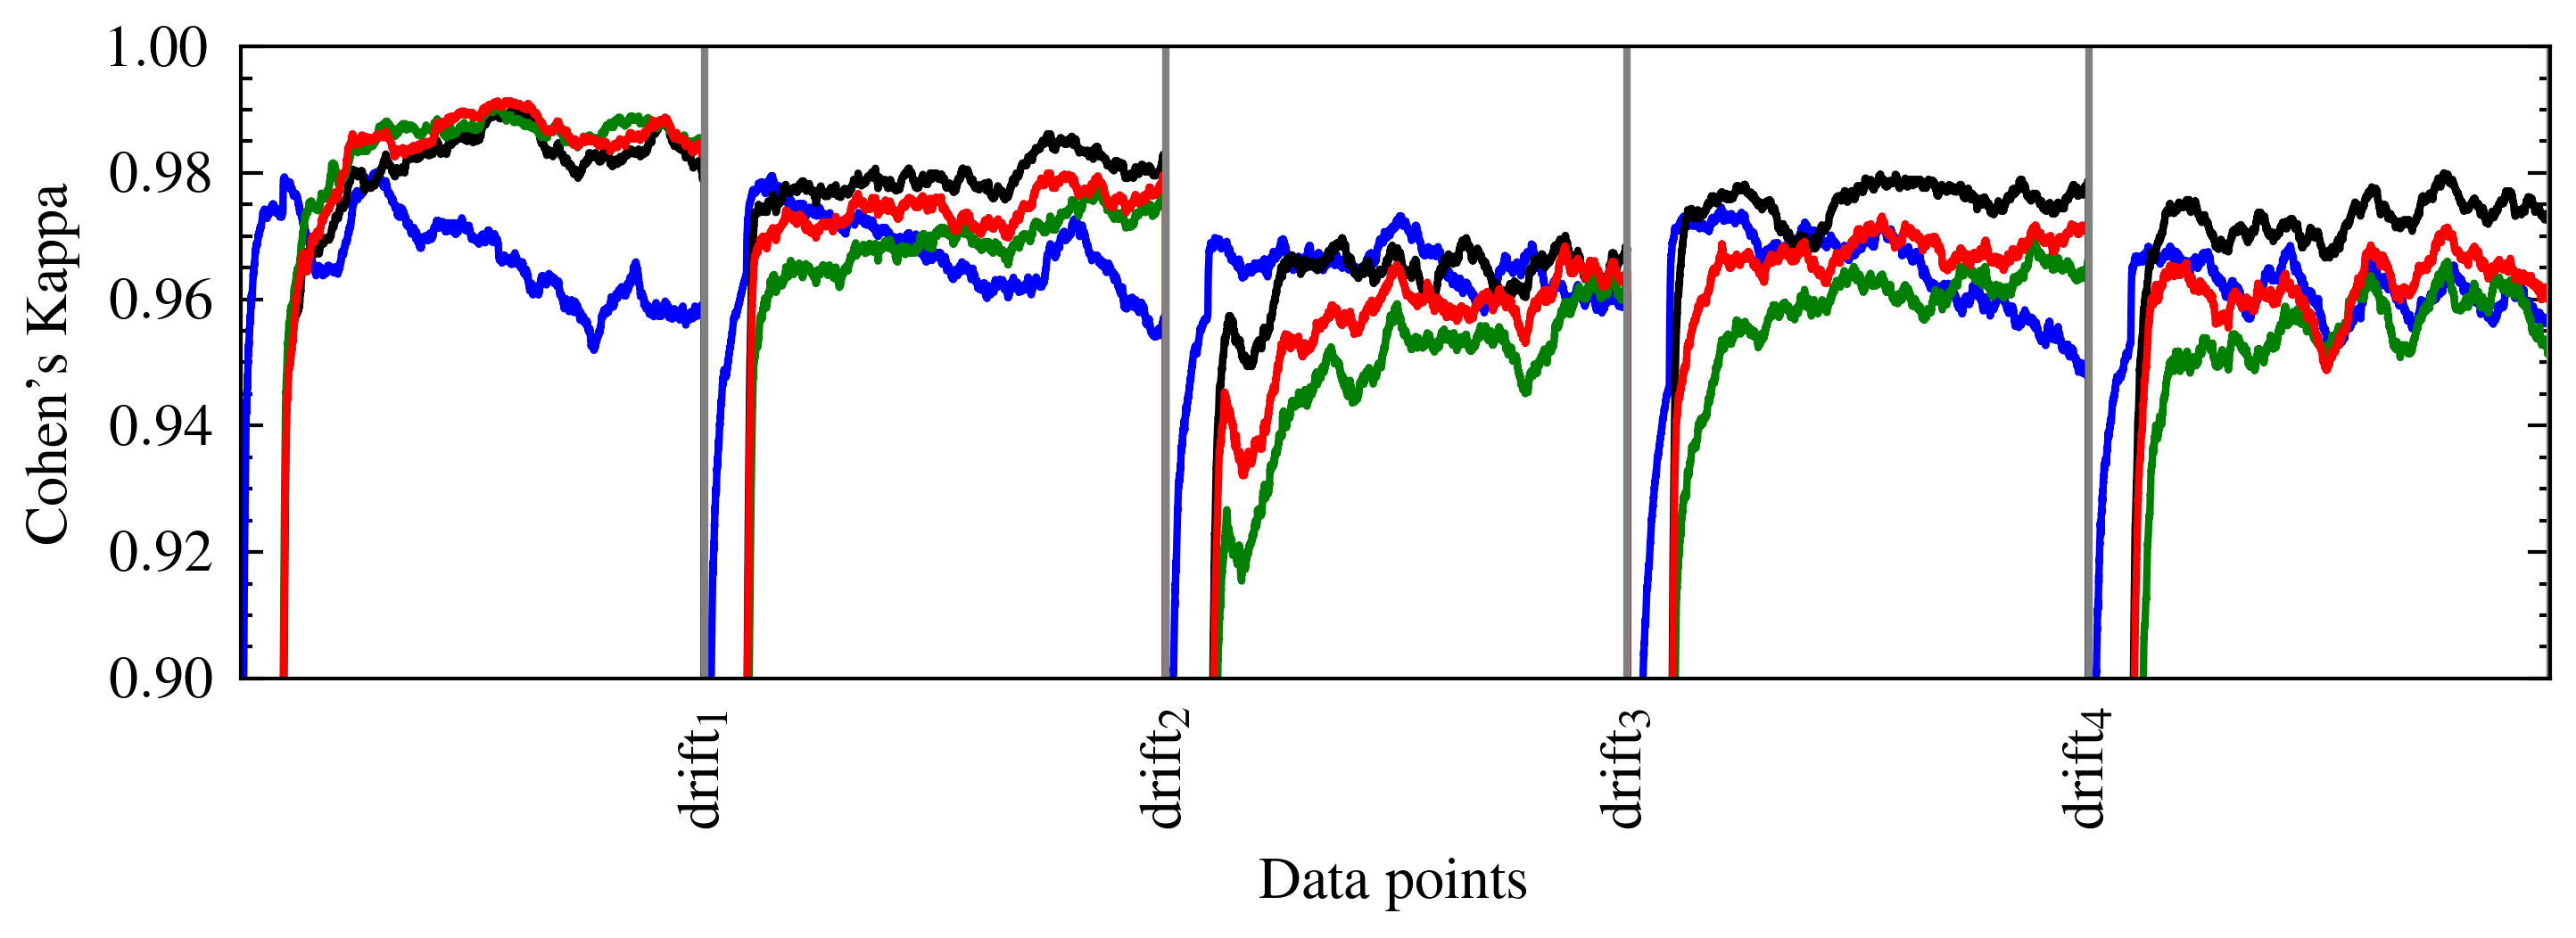


mnist_red30_sml rolling_reset_1000


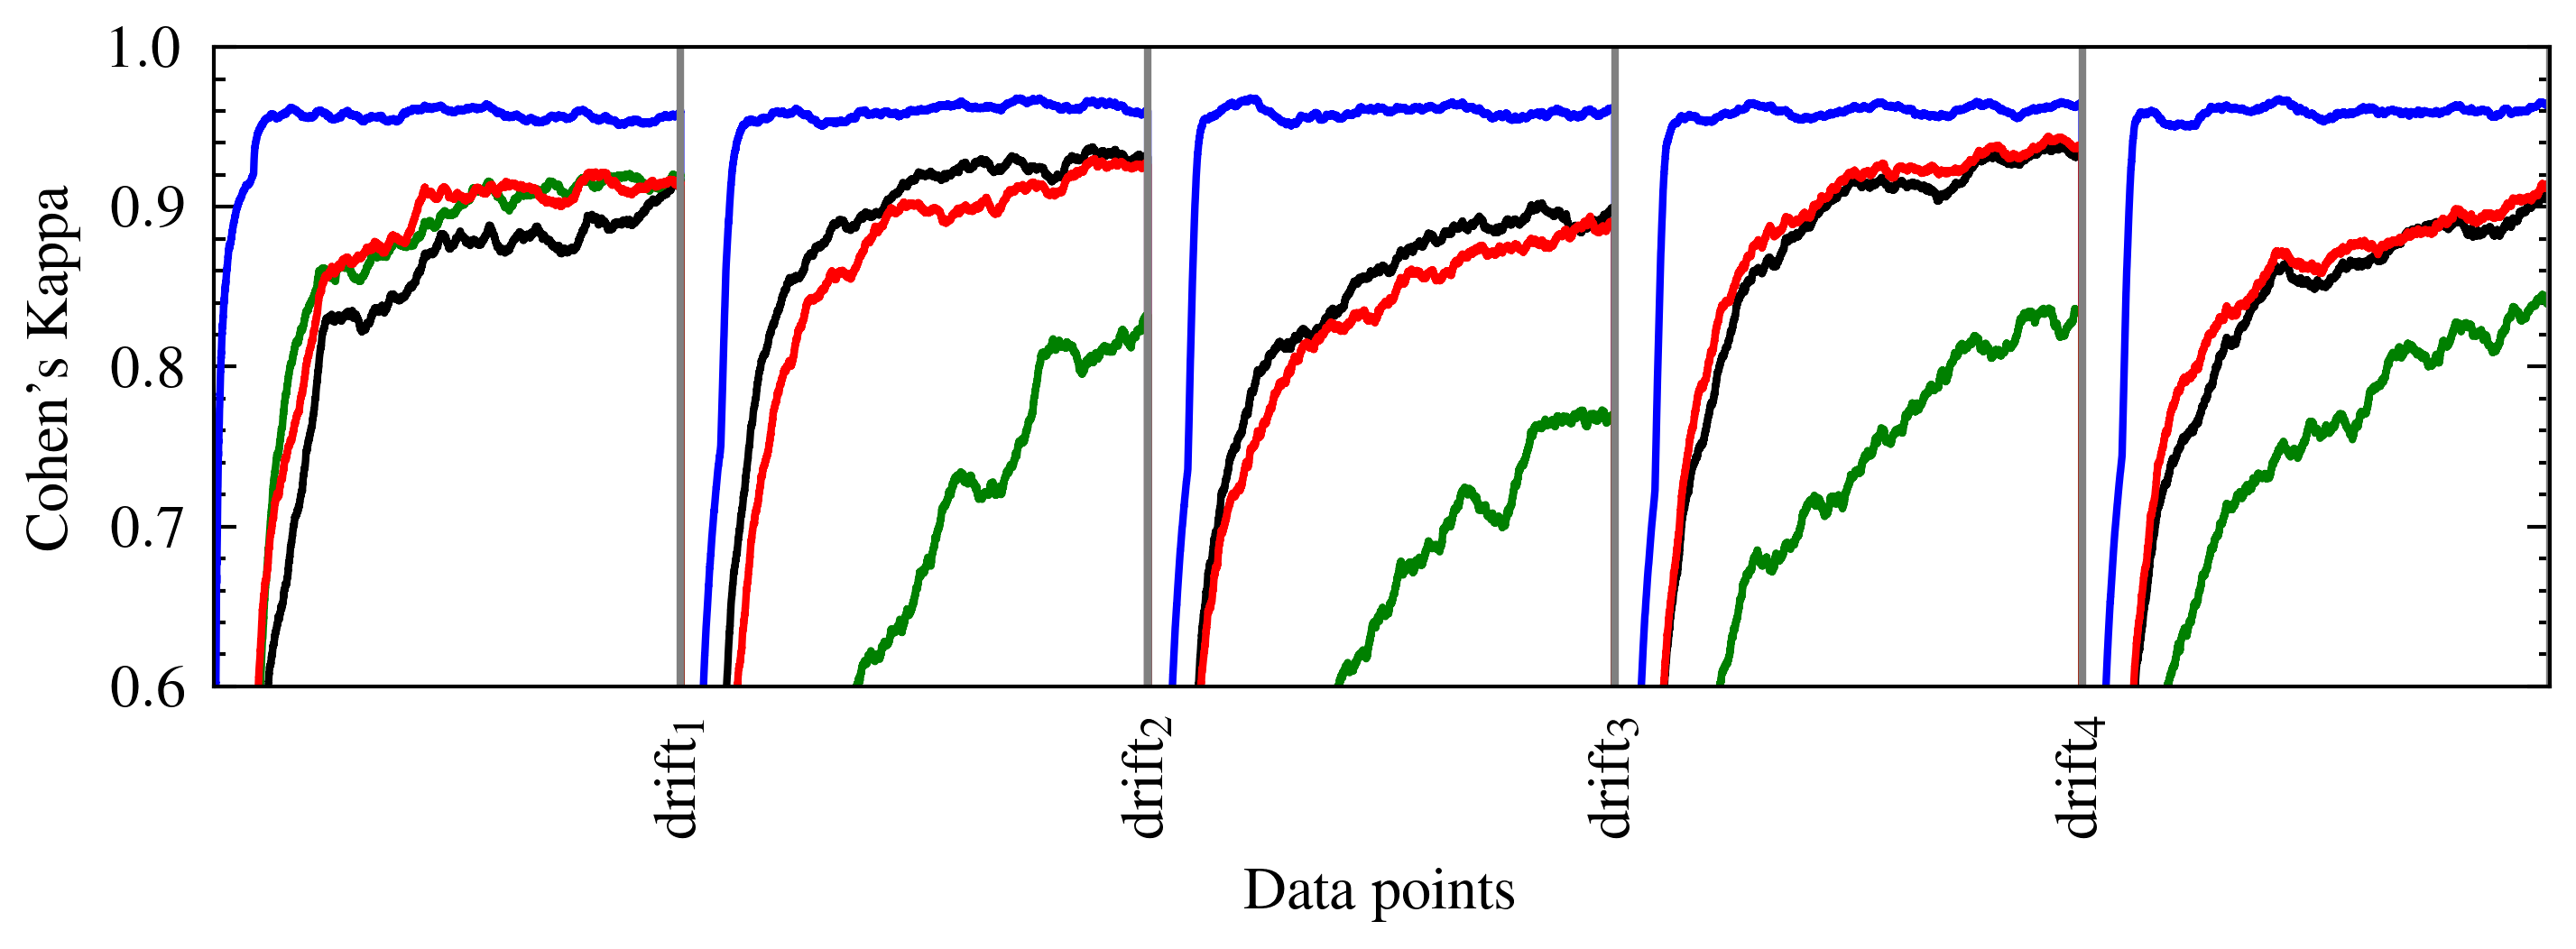

In [63]:
for dataset in datasets:
    for perf_type in ["rolling_reset_1000"]:
        print(dataset, perf_type)
        plot_metric(perf_values_final[dataset], root=os.path.join(root, "performance"), dataset=dataset, perf=perf_type, metric="kappa")
    print()

/var/folders/8b/bn5g5hn14bv56xr733msk9tr0000gn/T/ipykernel_25141/4071508643.py:48: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


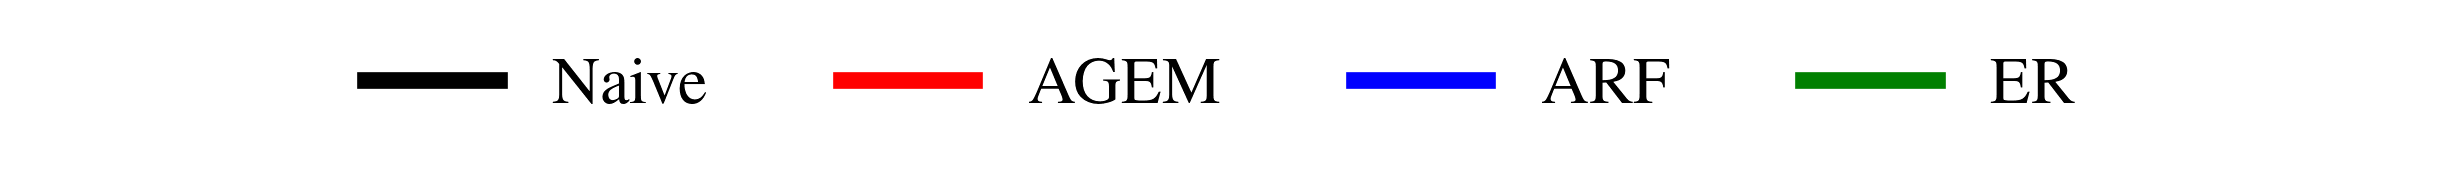

In [51]:
import matplotlib.pyplot as plt
import scienceplots

def rename_model(x):
    if x=="naive":
        return "Naive"
    return x.upper()

cm = 1 / 2.54

plt.style.use(['science', 'ieee'])
plt.rcParams.update({'font.size': 8})

# Creazione di una figura vuota per la legenda
fig, ax = plt.subplots(figsize=(13*cm, 0.1*cm))  # Larghezza personalizzabile
ax.axis('off')  # Nascondiamo gli assi

# Dati per la legenda

colors = plt.rcParams['axes.prop_cycle'].by_key()['color'] + []
extra_colors = [
    '#e41a1c',  # rosso vivo
    '#377eb8',  # blu acceso
    '#4daf4a',  # verde brillante
    '#984ea3',  # viola intenso
    '#ff7f00',  # arancione scuro
    '#ffff33',  # giallo limone (usa con sfondi scuri)
]
colors += extra_colors
models = ["naive"] + sorted([x for x in list(perf_values_final[datasets[0]].keys()) if x!="drifts" and x!="naive"])

colors = [colors[i] for i in range(len(models))]
linestyles = ['-' for _ in models]

# Generazione delle linee di legenda
lines = [plt.Line2D([0], [0], color=color, linestyle=linestyle, lw=2) for color, linestyle in zip(colors, linestyles)]

# Creazione della legenda
legend = ax.legend(
    lines, [rename_model(m) for m in models],
    loc='center',
    ncol=len(models),  # Per ottenere una legenda orizzontale
    frameon=False,
    fontsize=8
)

# Salvataggio della figura
plt.tight_layout()
plt.savefig(os.path.join('legend.eps'), format="eps", bbox_inches='tight')

In [54]:
import pickle

In [55]:
rooth = "/Users/federicogiannini/Library/CloudStorage/OneDrive-PolitecnicodiMilano/SML_CL/performance"